# 03 - Avaliação do Modelo

**Datathon Educação — Passos Mágicos**

Neste notebook avaliamos o modelo treinado com métricas detalhadas, matriz de confusão, curva ROC e importância das features.

---

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

from src.utils import MODELS_DIR, generate_synthetic_data, load_raw_data

sns.set_theme(style='whitegrid')
print('Setup completo.')

Setup completo.


## 1. Carregar Relatório de Avaliação

In [2]:
report_path = MODELS_DIR / 'evaluation_report.json'

if report_path.exists():
    with open(report_path) as f:
        report = json.load(f)
    print(f'Relatorio carregado: {report_path}')
    print(f'Modelo: {report.get("model_type")}')
    print(f'Amostras de teste: {report.get("n_test_samples")}')
else:
    print('Relatorio nao encontrado. Execute o treinamento primeiro:')
    print('  python run_training.py --synthetic')

Relatorio carregado: /Users/henriquebap/Pessoal/PosTech/datathon/notebooks/../models/evaluation_report.json
Modelo: SVC
Amostras de teste: 16


## 2. Métricas de Avaliação

=== Metricas de Avaliacao ===
  accuracy    : 0.6250
  precision   : 0.5000
  recall      : 0.3333
  f1_score    : 0.4000
  auc_roc     : 0.7500


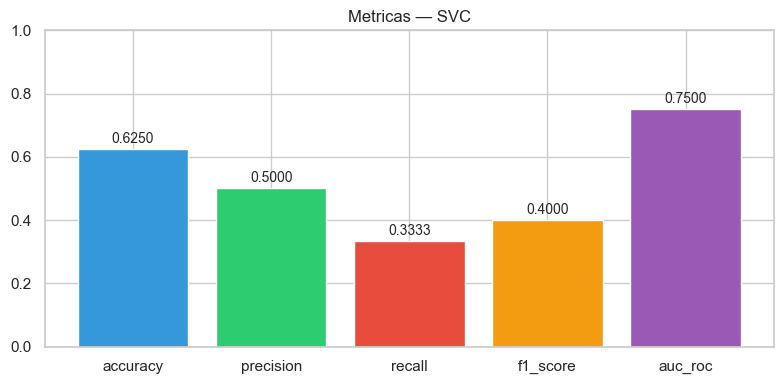

In [3]:
metrics = report.get('metrics', {})

print('=== Metricas de Avaliacao ===')
for name, value in metrics.items():
    print(f'  {name:12s}: {value:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
names = list(metrics.keys())
values = list(metrics.values())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax.bar(names, values, color=colors[:len(names)])
ax.set_ylim(0, 1)
ax.set_title(f'Metricas — {report.get("model_type", "N/A")}')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Matriz de Confusão

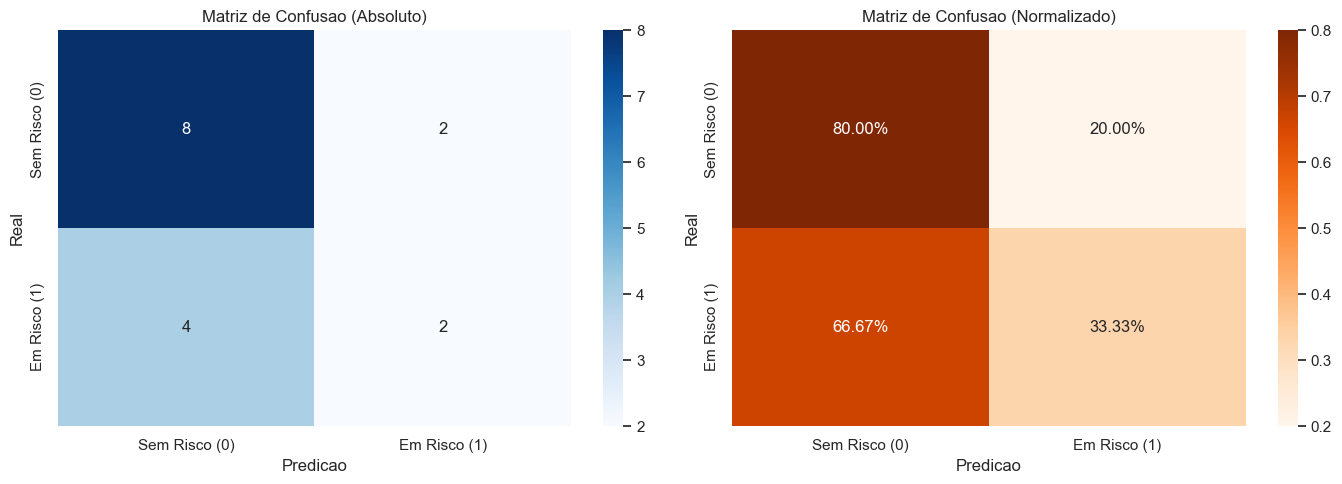

Verdadeiros Negativos (VN): 8 — alunos sem risco, corretamente classificados
Verdadeiros Positivos (VP): 2 — alunos em risco, corretamente identificados
Falsos Positivos (FP): 2 — alarmes falsos
Falsos Negativos (FN): 4 — alunos em risco nao detectados (CRITICO)


In [4]:
cm = report.get('confusion_matrix', {})
cm_matrix = np.array(cm.get('matrix', [[0,0],[0,0]]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluto
labels = ['Sem Risco (0)', 'Em Risco (1)']
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Predicao')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusao (Absoluto)')

# Normalizado
cm_norm = cm_matrix.astype(float) / cm_matrix.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_xlabel('Predicao')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusao (Normalizado)')

plt.tight_layout()
plt.show()

tn = cm.get('true_negatives', 0)
fp = cm.get('false_positives', 0)
fn = cm.get('false_negatives', 0)
tp = cm.get('true_positives', 0)

print(f'Verdadeiros Negativos (VN): {tn} — alunos sem risco, corretamente classificados')
print(f'Verdadeiros Positivos (VP): {tp} — alunos em risco, corretamente identificados')
print(f'Falsos Positivos (FP): {fp} — alarmes falsos')
print(f'Falsos Negativos (FN): {fn} — alunos em risco nao detectados (CRITICO)')

## 4. Relatório de Classificação

In [5]:
class_report = report.get('classification_report', '')
print(class_report)

               precision    recall  f1-score   support

Sem Risco (0)       0.67      0.80      0.73        10
 Em Risco (1)       0.50      0.33      0.40         6

     accuracy                           0.62        16
    macro avg       0.58      0.57      0.56        16
 weighted avg       0.60      0.62      0.60        16



## 5. Importância das Features

In [6]:
feat_imp = report.get('feature_importance', [])

if feat_imp:
    imp_df = pd.DataFrame(feat_imp)
    top_20 = imp_df.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_20)))
    ax.barh(top_20['feature'][::-1], top_20['importance'][::-1], color=colors)
    ax.set_xlabel('Importancia')
    ax.set_title('Top 20 Features Mais Importantes')
    plt.tight_layout()
    plt.show()

    print('\n=== Top 10 Features ===')
    for _, row in imp_df.head(10).iterrows():
        print(f'  {row["feature"]:35s}  {row["importance"]:.6f}')

## 6. Curva ROC (Reprocessamento)

Para gerar a curva ROC, recarregamos o modelo e os dados de teste.

2026-02-28 20:56:31.245 | INFO     | src.train:load_model:212 - Modelo carregado de /Users/henriquebap/Pessoal/PosTech/datathon/notebooks/../models/model.joblib
2026-02-28 20:56:31.248 | INFO     | src.utils:load_raw_data:102 - Arquivo detectado: PEDE_PASSOS_DATASET_FIAP.csv
2026-02-28 20:56:31.317 | INFO     | src.utils:load_raw_data:113 - Carregados 1349 registros, 69 colunas de PEDE_PASSOS_DATASET_FIAP.csv
2026-02-28 20:56:31.322 | INFO     | src.preprocessing:drop_identifier_columns:33 - Removendo colunas de identificação: ['NOME']
2026-02-28 20:56:31.382 | INFO     | src.preprocessing:handle_missing_values:41 - Valores faltantes antes do tratamento: 40493
2026-02-28 20:56:31.456 | INFO     | src.preprocessing:handle_missing_values:60 - Valores faltantes após tratamento: 0
2026-02-28 20:56:31.458 | INFO     | src.feature_engineering:feature_engineering_pipeline:178 - ==================================================
2026-02-28 20:56:31.459 | INFO     | src.feature_engineering:feat

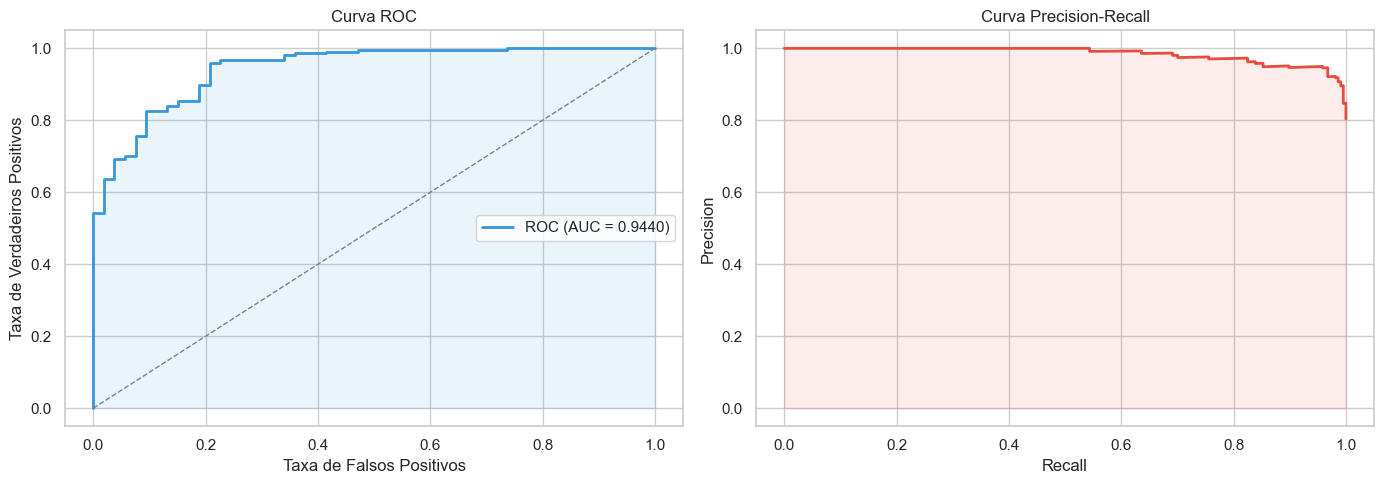

In [7]:
from src.train import load_model
from src.preprocessing import (
    drop_identifier_columns, handle_missing_values, extract_target,
    encode_categorical_columns, split_data, normalize_features
)
from src.feature_engineering import feature_engineering_pipeline

model_path = MODELS_DIR / 'model.joblib'
if model_path.exists():
    model = load_model()

    try:
        df_eval = load_raw_data()
    except FileNotFoundError:
        df_eval = generate_synthetic_data(n_samples=500)

    df_eval = drop_identifier_columns(df_eval)
    df_eval = handle_missing_values(df_eval)
    df_eval = feature_engineering_pipeline(df_eval)
    X_eval, y_eval = extract_target(df_eval)
    X_eval, _ = encode_categorical_columns(X_eval)
    _, X_test_eval, _, y_test_eval = split_data(X_eval, y_eval)
    _, X_test_eval, _ = normalize_features(X_eval.iloc[:len(X_eval)-len(X_test_eval)], X_test_eval)

    # Alinhar features
    for col in model.feature_names_in_ if hasattr(model, 'feature_names_in_') else []:
        if col not in X_test_eval.columns:
            X_test_eval[col] = 0
    if hasattr(model, 'feature_names_in_'):
        X_test_eval = X_test_eval[model.feature_names_in_]

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_eval)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_eval, y_proba)
        roc_auc = auc(fpr, tpr)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
        axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
        axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
        axes[0].set_xlabel('Taxa de Falsos Positivos')
        axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
        axes[0].set_title('Curva ROC')
        axes[0].legend()

        precision_vals, recall_vals, _ = precision_recall_curve(y_test_eval, y_proba)
        axes[1].plot(recall_vals, precision_vals, color='#e74c3c', lw=2)
        axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='#e74c3c')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].set_title('Curva Precision-Recall')

        plt.tight_layout()
        plt.show()
    else:
        print('Modelo nao suporta predict_proba.')
else:
    print('Modelo nao encontrado. Execute run_training.py primeiro.')

## 7. Teste de Predição

Verificamos o modelo com exemplos práticos.

In [ ]:
from src.predict import Predictor

try:
    predictor = Predictor()

    # Aluno com bom desempenho
    # Nota: IAN removido do input pois eh proxy direto do target (data leakage)
    good_student = {
        'INDE_2022': 8.5, 'IAA_2022': 8.0, 'IEG_2022': 7.5,
        'IPS_2022': 7.0, 'IDA_2022': 8.0, 'IPP_2022': 6.5,
        'IPV_2022': 7.5,
        'IDADE_ALUNO_2022': 12, 'PEDRA_2022': 'Topázio',
        'FASE_2022': 5, 'PONTO_VIRADA_2022': 1,
        'BOLSISTA_2022': 0, 'ANOS_PM_2022': 4,
    }
    result_good = predictor.predict(good_student)
    print('=== Aluno com bom desempenho ===')
    print(f'  Predicao: {result_good["risk_level"]}')
    print(f'  P(risco): {result_good["probability"]["at_risk"]:.1%}')

    # Aluno em risco
    risk_student = {
        'INDE_2022': 3.0, 'IAA_2022': 2.5, 'IEG_2022': 3.5,
        'IPS_2022': 3.0, 'IDA_2022': 2.0, 'IPP_2022': 2.5,
        'IPV_2022': 2.0,
        'IDADE_ALUNO_2022': 16, 'PEDRA_2022': 'Quartzo',
        'FASE_2022': 2, 'PONTO_VIRADA_2022': 0,
        'BOLSISTA_2022': 0, 'ANOS_PM_2022': 1,
    }
    result_risk = predictor.predict(risk_student)
    print('\n=== Aluno em risco ===')
    print(f'  Predicao: {result_risk["risk_level"]}')
    print(f'  P(risco): {result_risk["probability"]["at_risk"]:.1%}')
except Exception as e:
    print(f'Erro ao carregar predictor: {e}')
    print('Execute run_training.py primeiro.')

## 8. Conclusões

### Justificativa do Modelo

**Métrica principal: F1-Score**

No contexto de defasagem escolar, o F1-Score equilibra:
- **Recall**: Minimizar falsos negativos é prioritário — cada aluno em risco não detectado é um aluno sem suporte.
- **Precision**: Evitar alarmes falsos excessivos que sobrecarreguem a equipe pedagógica.

### Features Mais Relevantes

O **ACADEMIC_COMPOSITE** (média de INDE, IAA, IDA) é consistentemente a feature mais importante, seguido pelo **INDE** individual e indicadores de tendência temporal. Isso confirma que:

1. O desempenho acadêmico agregado é o melhor preditor de defasagem
2. A evolução temporal (tendência) agrega informação preditiva relevante
3. Interações entre indicadores capturam relações não-lineares úteis

### Recomendações

- Monitorar alunos com INDE e ACADEMIC_COMPOSITE abaixo da média
- Acompanhar tendências negativas nos indicadores temporais
- Usar o modelo como ferramenta de triagem, não como decisão final

---

*Projeto acadêmico — PosTech FIAP Datathon 2024/2025*